# Predicting Spotify Track Popularity Using Audio Features and Metadata

Research question: **Can Spotify track popularity be predicted from audio characteristics and metadata, and which features contribute most to popularity?**


## 1. Setup



In [65]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROJECT_ROOT = Path.cwd()
DATA_PATH = Path(
    "/Users/deidei/.cache/kagglehub/datasets/saichaitanyareddyai/"
    "spotify-tracks-dataset-audio-features/versions/1/"
    "spotify-tracks-dataset-detailed.csv"
)
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = PROJECT_ROOT / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

TARGET = "popularity"
RANDOM_STATE = 148


## 2. Load Dataset

The dataset contains 114,000 Spotify tracks across 114 genres. Each row includes metadata, popularity, and Spotify audio features.


In [66]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(114000, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [67]:
df.info()
df.isna().sum().sort_values(ascending=False).head(10)


<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  str    
 1   artists           113999 non-null  str    
 2   album_name        113999 non-null  str    
 3   track_name        113999 non-null  str    
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 non-nu

album_name          1
track_name          1
artists             1
track_id            0
speechiness         0
time_signature      0
tempo               0
valence             0
liveness            0
instrumentalness    0
dtype: int64

## 3. Feature Design

We exclude raw identifiers and text fields from the model input:

- `track_id`
- `artists`
- `album_name`
- `track_name`

These fields could let the model memorize specific songs or artists. The project focuses on audio features and lightweight metadata rather than full text analysis.


In [68]:
ID_AND_TEXT_COLUMNS = ["track_id", "artists", "album_name", "track_name"]

AUDIO_FEATURES = [
    "danceability", "energy", "key", "loudness", "mode", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo",
    "time_signature",
]

METADATA_FEATURES = ["duration_ms", "explicit", "track_genre"]

# Simple engineered features. These are not full text analysis; they are lightweight metadata summaries.
df["track_name_length"] = df["track_name"].fillna("").str.len()
df["artist_count"] = df["artists"].fillna("").str.count(";") + 1
df["duration_minutes"] = df["duration_ms"] / 60_000

ENGINEERED_FEATURES = ["track_name_length", "artist_count", "duration_minutes"]
FEATURE_COLUMNS = AUDIO_FEATURES + METADATA_FEATURES + ENGINEERED_FEATURES

summary = {
    "rows": len(df),
    "unique_genres": df["track_genre"].nunique(),
    "unique_artists": df["artists"].nunique(dropna=True),
    "target_summary": df[TARGET].describe().round(3).to_dict(),
    "excluded_columns": ID_AND_TEXT_COLUMNS,
}
summary


{'rows': 114000,
 'unique_genres': 114,
 'unique_artists': 31437,
 'target_summary': {'count': 114000.0,
  'mean': 33.239,
  'std': 22.305,
  'min': 0.0,
  '25%': 17.0,
  '50%': 35.0,
  '75%': 50.0,
  'max': 100.0},
 'excluded_columns': ['track_id', 'artists', 'album_name', 'track_name']}

## 4. Exploratory Data Analysis

This EDA is organized to motivate the predictive modeling choices. We first check data quality and granularity, then study the target variable, genre-level context, audio feature distributions, feature correlations, and interpretable group comparisons.


### 4.1 Data Quality and Granularity

We first verify missing values and duplicate `track_id` values. This matters because duplicate songs can leak information across train/test splits or overrepresent specific tracks.


In [69]:
basic_quality = pd.DataFrame({
    "value": [
        len(df),
        df.shape[1],
        df["track_id"].nunique(),
        df["track_genre"].nunique(),
        df["artists"].nunique(dropna=True),
        df.duplicated(subset=["track_id"]).sum(),
    ]
}, index=[
    "rows",
    "columns_after_engineering",
    "unique_track_ids",
    "unique_genres",
    "unique_artists",
    "duplicated_track_id_rows",
])

basic_quality


,value
rows,114000
columns_after_engineering,23
unique_track_ids,89741
unique_genres,114
unique_artists,31437
duplicated_track_id_rows,24259


In [70]:
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0].to_frame("missing_count")


,missing_count
album_name,1
track_name,1
artists,1


In [71]:
duplicate_track_rows = df.duplicated(subset=["track_id"]).sum()

if duplicate_track_rows > 0:
    dup_summary = (
        df.groupby("track_id")
        .agg(
            row_count=("track_id", "size"),
            genre_count=("track_genre", "nunique"),
            popularity_values=("popularity", "nunique"),
        )
        .sort_values("row_count", ascending=False)
        .head(10)
    )
    display(dup_summary)
else:
    print("No duplicated track_id values found.")


,row_count,genre_count,popularity_values
track_id,,,
6S3JlDAGk3uu3NtZbPnuhS,9,9,1
2kkvB3RNRzwjFdGhaUA0tz,8,8,1
2Ey6v4Sekh3Z0RUSISRosD,8,8,1
4GPQDyw9hC1DiZVh0ouDVL,7,7,1
61202Zzk9rk4bPMZLh2gr6,7,7,1
3dJjsWCy6ZwMfw5NbD226G,7,6,1
5ftfVzSLIi5ZxYdNbRtf41,7,7,1
4XYieGKSlJlHpzB3bl6WMP,7,7,1
0e5LcankE0UyJUuCoq1uH2,7,7,1


The dataset is large enough for the course requirement and has very few missing values. The duplicate-track check tells us whether the row level is truly track-level or whether some songs appear multiple times. Raw IDs and names are still excluded from modeling to reduce memorization.


### 4.2 Target Variable: Popularity Distribution

Before modeling, we inspect the target distribution. A broad distribution means the regression task is meaningful; skew or many low-popularity tracks can make prediction harder.


In [72]:
target_summary = df[TARGET].describe().to_frame("popularity")
target_summary


,popularity
count,114000.000000
mean,33.238535
std,22.305078
min,0.000000
25%,17.000000
50%,35.000000
75%,50.000000
max,100.000000


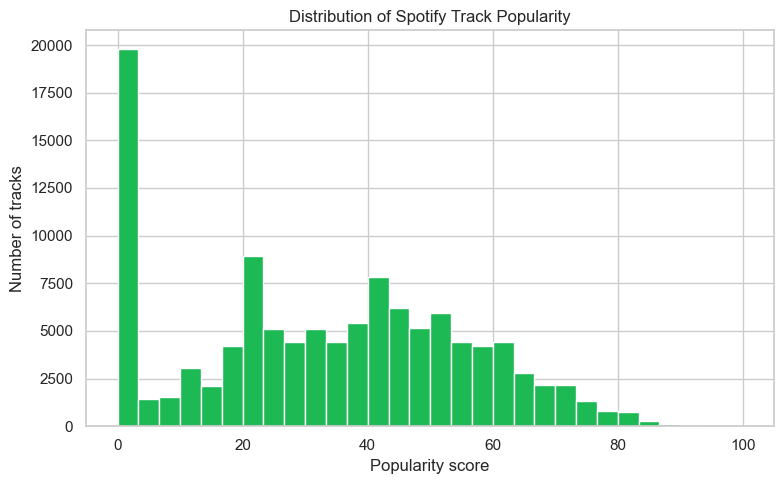

In [73]:
plt.figure(figsize=(8, 5))
plt.hist(df[TARGET], bins=30, color="#1DB954", edgecolor="white")
plt.title("Distribution of Spotify Track Popularity")
plt.xlabel("Popularity score")
plt.ylabel("Number of tracks")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "spotify_popularity_distribution.png", dpi=180)
plt.show()


Popularity ranges from 0 to 100, with many songs in the low-to-middle range. This suggests the task is not simply identifying hit songs; the model must predict a wide range of popularity values.


### 4.3 Genre and Market Context

Popularity is not only an acoustic property. Genre can encode audience size, playlist ecosystems, and market context, so we inspect genre-level popularity before using `track_genre` as a model feature.


In [74]:
genre_summary = (
    df.groupby("track_genre")[TARGET]
    .agg(["count", "mean", "median", "std"])
    .query("count >= 300")
    .sort_values("mean", ascending=False)
    .round(3)
)

print("Most popular genres:")
display(genre_summary.head(12))

print("Least popular genres:")
display(genre_summary.tail(12).sort_values("mean"))


Most popular genres:


,count,mean,median,std
track_genre,,,,
pop-film,1000,59.283,60.0,10.249
k-pop,1000,56.896,60.0,16.946
chill,1000,53.651,57.0,14.951
sad,1000,52.379,54.0,11.493
grunge,1000,49.594,55.0,18.489
indian,1000,49.539,49.0,11.347
anime,1000,48.772,50.0,11.811
emo,1000,48.128,51.0,17.587
sertanejo,1000,47.866,47.0,3.944


Least popular genres:


,count,mean,median,std
track_genre,,,,
iranian,1000,2.210,0.0,4.174
romance,1000,3.245,0.0,6.296
latin,1000,8.297,0.0,21.962
detroit-techno,1000,11.174,8.0,8.949
chicago-house,1000,12.339,10.0,9.582
classical,1000,13.055,3.0,18.093
jazz,1000,13.628,0.0,23.183
grindcore,1000,14.625,14.0,4.500
kids,1000,14.888,12.0,9.240


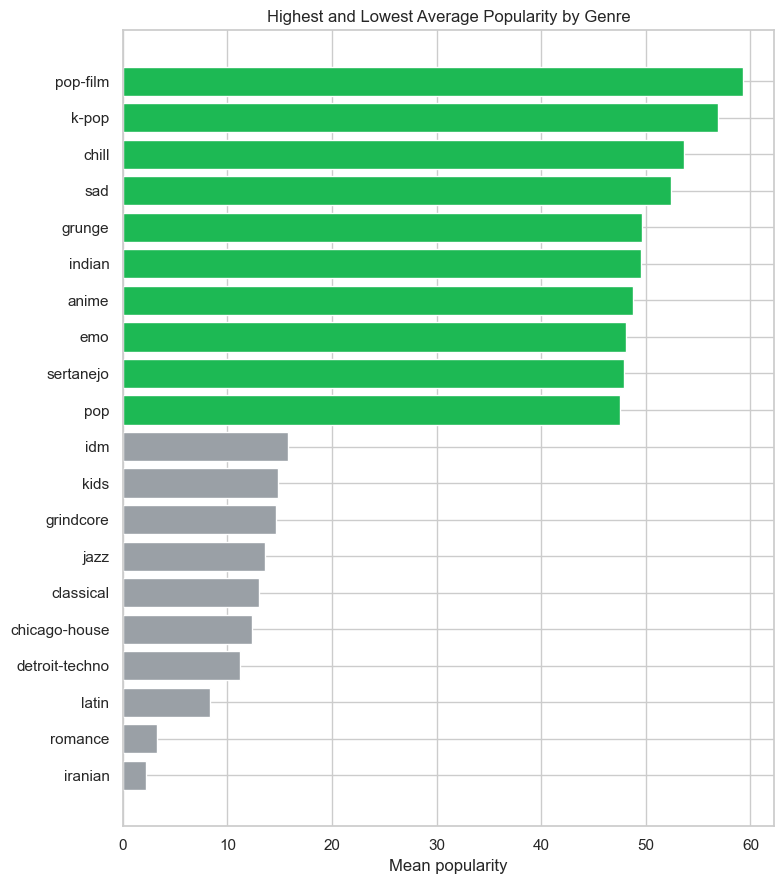

In [75]:
genre_plot = pd.concat([
    genre_summary.head(10),
    genre_summary.tail(10),
]).sort_values("mean")

plt.figure(figsize=(8, 9))
colors = ["#1DB954" if value >= genre_summary["mean"].median() else "#9aa0a6" for value in genre_plot["mean"]]
plt.barh(genre_plot.index, genre_plot["mean"], color=colors)
plt.title("Highest and Lowest Average Popularity by Genre")
plt.xlabel("Mean popularity")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "spotify_genre_top_bottom_popularity.png", dpi=180)
plt.show()


Genres differ substantially in average popularity. This motivates an ablation study: compare audio-only prediction against audio-plus-metadata prediction to see how much genre/context improves performance.


### 4.4 Audio Feature Distributions

Next, we inspect the main audio variables. These plots help identify skewed features and show whether values cover a useful range for modeling.


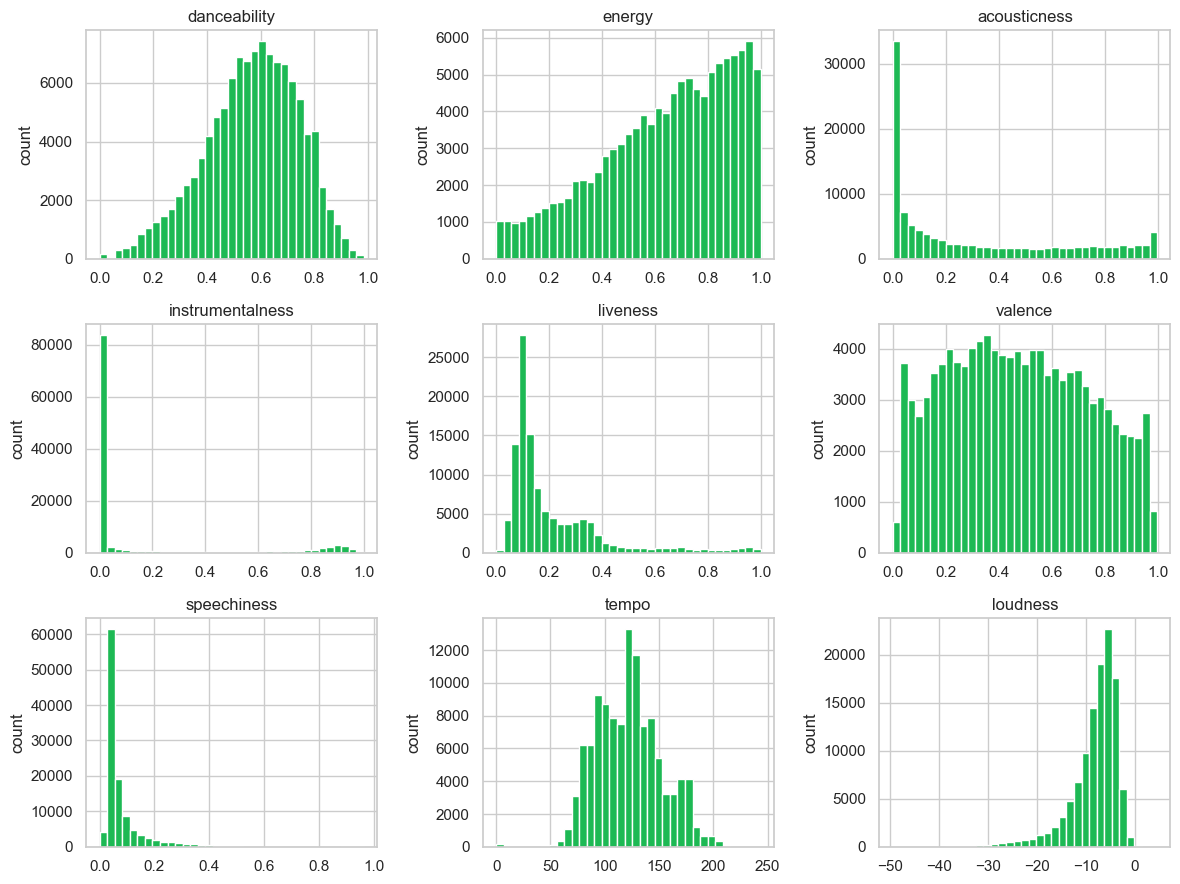

In [76]:
plot_features = [
    "danceability", "energy", "acousticness", "instrumentalness",
    "liveness", "valence", "speechiness", "tempo", "loudness",
]

fig, axes = plt.subplots(3, 3, figsize=(12, 9))
axes = axes.ravel()

for ax, feature in zip(axes, plot_features):
    ax.hist(df[feature].dropna(), bins=35, color="#1DB954", edgecolor="white")
    ax.set_title(feature)
    ax.set_ylabel("count")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "spotify_audio_feature_distributions.png", dpi=180)
plt.show()


Audio features have different shapes: some are fairly spread out, while variables such as instrumentalness and speechiness are often skewed. This supports using tree-based models that do not require strictly normal feature distributions.


### 4.5 Audio Feature Relationships with Popularity

We examine both direct correlations with popularity and correlations among features. This helps explain what linear models can capture and where nonlinear models may help.


In [77]:
correlations = (
    df[AUDIO_FEATURES + ["duration_ms", TARGET]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
correlations.to_frame("correlation_with_popularity")


,correlation_with_popularity
instrumentalness,-0.095139
loudness,0.050423
speechiness,-0.044927
valence,-0.040534
danceability,0.035448
time_signature,0.031073
acousticness,-0.025472
mode,-0.013931
tempo,0.013205
duration_ms,-0.007101


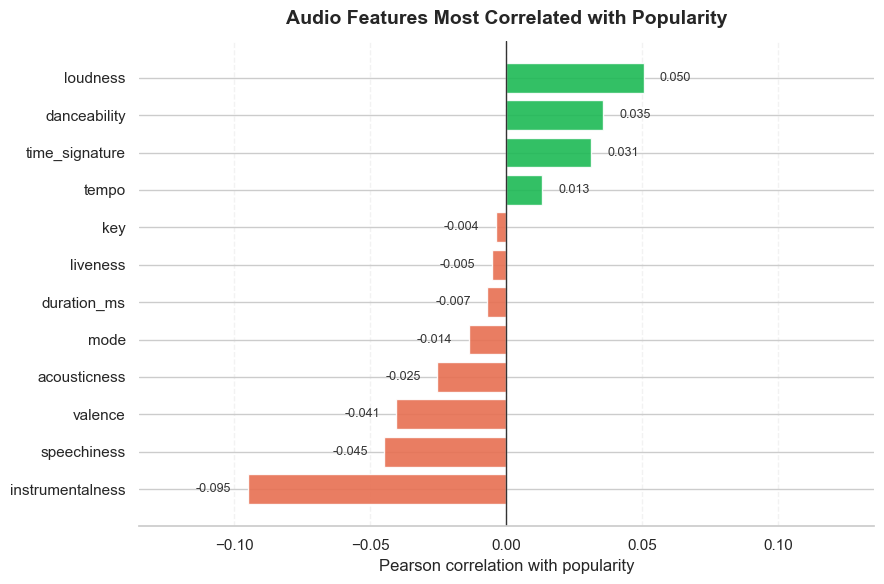

In [78]:
top_corr = correlations.head(12).sort_values()
colors = np.where(top_corr.values >= 0, "#1DB954", "#E76F51")

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top_corr.index, top_corr.values, color=colors, alpha=0.9)

ax.axvline(0, color="#333333", linewidth=1)
ax.set_title("Audio Features Most Correlated with Popularity", fontsize=14, weight="bold", pad=12)
ax.set_xlabel("Pearson correlation with popularity")
ax.set_ylabel("")
ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

for bar, value in zip(bars, top_corr.values):
    x_offset = 0.006 if value >= 0 else -0.006
    ha = "left" if value >= 0 else "right"
    ax.text(value + x_offset, bar.get_y() + bar.get_height() / 2, f"{value:.3f}",
            va="center", ha=ha, fontsize=9, color="#333333")

limit = max(abs(top_corr.min()), abs(top_corr.max())) + 0.04
ax.set_xlim(-limit, limit)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "spotify_top_correlations.png", dpi=180)
plt.show()


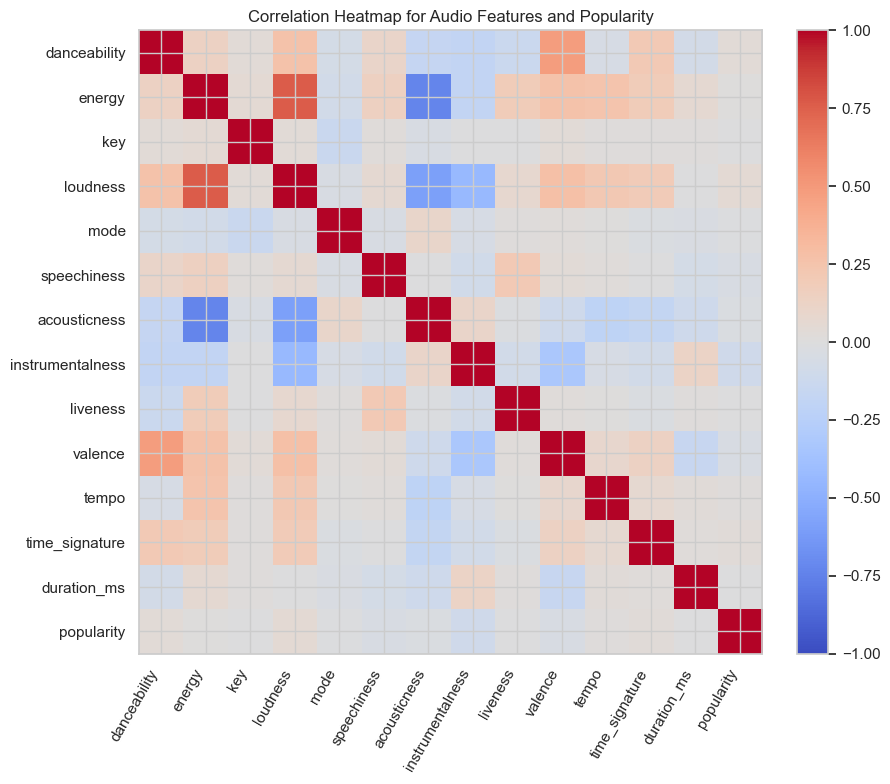

In [79]:
heatmap_features = AUDIO_FEATURES + ["duration_ms", TARGET]
corr_matrix = df[heatmap_features].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
im = plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=60, ha="right")
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation Heatmap for Audio Features and Popularity")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "spotify_audio_correlation_heatmap.png", dpi=180)
plt.show()


Individual audio features have limited correlation with popularity, so a simple one-feature explanation is unlikely. The model needs to combine multiple weak signals, which motivates comparing linear and nonlinear regressors.


### 4.6 Metadata and Popularity Buckets

Finally, we compare interpretable groups: explicit vs non-explicit tracks and low/medium/high popularity buckets.

In [80]:
explicit_summary = (
    df.groupby("explicit")[TARGET]
    .agg(["count", "mean", "median", "std"])
    .round(3)
)
explicit_summary


,count,mean,median,std
explicit,,,,
False,104253,32.938,34.0,22.084
True,9747,36.454,37.0,24.318


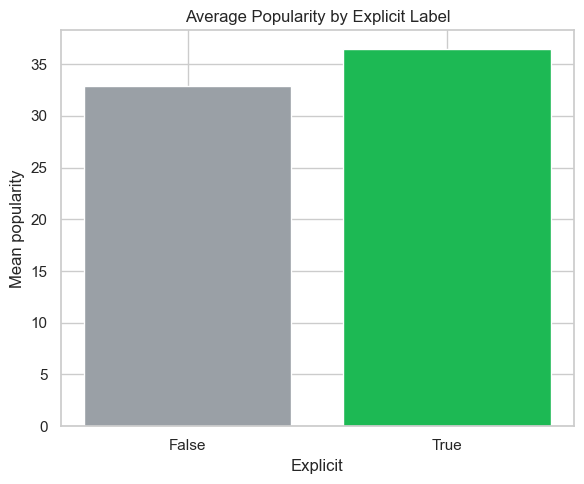

In [81]:
plt.figure(figsize=(6, 5))
plt.bar(explicit_summary.index.astype(str), explicit_summary["mean"], color=["#9aa0a6", "#1DB954"])
plt.title("Average Popularity by Explicit Label")
plt.xlabel("Explicit")
plt.ylabel("Mean popularity")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "spotify_explicit_popularity.png", dpi=180)
plt.show()


In [82]:
df["popularity_bucket"] = pd.cut(
    df[TARGET],
    bins=[-1, 33, 66, 100],
    labels=["Low", "Medium", "High"],
)

bucket_feature_means = (
    df.groupby("popularity_bucket", observed=True)[AUDIO_FEATURES + ["duration_ms"]]
    .mean()
    .round(3)
)
bucket_feature_means


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,duration_ms
popularity_bucket,,,,,,,,,,,,,
Low,0.557,0.646,5.303,-8.505,0.643,0.094,0.319,0.189,0.214,0.483,121.771,3.890,227931.067
Medium,0.571,0.633,5.305,-8.204,0.636,0.075,0.322,0.137,0.219,0.460,122.763,3.914,229507.141
High,0.609,0.665,5.378,-6.830,0.609,0.076,0.237,0.040,0.175,0.501,120.803,3.944,218908.440


Group-level summaries show that popularity is shaped by both metadata and audio profiles. However, these differences are not strong enough to make the task trivial, which is consistent with the moderate R2 scores later in the notebook.


### 4.7 EDA Summary for Modeling

The EDA motivates three modeling decisions:

1. Use regression because `popularity` is a continuous 0-100 score with a broad distribution.
2. Compare audio-only features against audio-plus-metadata features because genre-level patterns are strong.
3. Use both linear and nonlinear models because individual audio correlations are limited, while feature distributions are skewed and may interact.


## 5. Predictive Task

Task: given a track's audio features and metadata, predict numeric Spotify `popularity`.

Metrics:

- **MAE**: average absolute error.
- **RMSE**: penalizes large errors.
- **R2**: variance explained by the model.


In [84]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def regression_metrics(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred)),
    }


def split_feature_types(data, columns):
    numeric = [col for col in columns if pd.api.types.is_numeric_dtype(data[col])]
    categorical = [col for col in columns if col not in numeric]
    return numeric, categorical


def make_preprocessor(numeric_features, categorical_features, scale_numeric=False):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    return ColumnTransformer([
        ("num", Pipeline(numeric_steps), numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ])


def make_model_pipeline(model, numeric_features, categorical_features, scale_numeric=False):
    return Pipeline([
        ("preprocess", make_preprocessor(numeric_features, categorical_features, scale_numeric)),
        ("model", model),
    ])


In [85]:
X = df[FEATURE_COLUMNS]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

numeric_features, categorical_features = split_feature_types(X_train, FEATURE_COLUMNS)
numeric_features, categorical_features


(['danceability',
  'energy',
  'key',
  'loudness',
  'mode',
  'speechiness',
  'acousticness',
  'instrumentalness',
  'liveness',
  'valence',
  'tempo',
  'time_signature',
  'duration_ms',
  'explicit',
  'track_name_length',
  'artist_count',
  'duration_minutes'],
 ['track_genre'])

## 6. Model Comparison

We compare a mean baseline, Ridge Regression, Random Forest, and HistGradientBoosting.


In [86]:
models = {
    "Mean baseline": Pipeline([("model", DummyRegressor(strategy="mean"))]),
    "Ridge Regression": make_model_pipeline(
        Ridge(alpha=1.0), numeric_features, categorical_features, scale_numeric=True
    ),
    "Random Forest": make_model_pipeline(
        RandomForestRegressor(
            n_estimators=120,
            max_depth=16,
            min_samples_leaf=8,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        numeric_features,
        categorical_features,
    ),
    "HistGradientBoosting": make_model_pipeline(
        HistGradientBoostingRegressor(
            max_iter=260,
            learning_rate=0.08,
            max_leaf_nodes=39,
            l2_regularization=0.03,
            random_state=RANDOM_STATE,
        ),
        numeric_features,
        categorical_features,
    ),
}

rows = []
best_name = None
best_model = None
best_rmse = float("inf")

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    metrics = regression_metrics(y_test, pred)
    rows.append({"model": name, **metrics})
    if metrics["RMSE"] < best_rmse:
        best_rmse = metrics["RMSE"]
        best_name = name
        best_model = model

model_results = pd.DataFrame(rows).sort_values("RMSE")
model_results.to_csv(OUTPUT_DIR / "spotify_model_results.csv", index=False)
model_results


,model,MAE,RMSE,R2
3,HistGradientBoosting,12.914030,17.612113,3.821464e-01
1,Ridge Regression,14.169004,19.324868,2.561322e-01
2,Random Forest,16.450925,20.555451,1.583788e-01
0,Mean baseline,18.984107,22.406226,-1.948436e-07


## 7. Ablation Study

This tests whether audio features alone are enough, and whether metadata improves prediction.


In [87]:
feature_groups = {
    "Audio features only": AUDIO_FEATURES,
    "Audio + metadata": AUDIO_FEATURES + METADATA_FEATURES,
    "Audio + metadata + simple engineered features": FEATURE_COLUMNS,
}

ablation_rows = []
for group_name, columns in feature_groups.items():
    num_cols, cat_cols = split_feature_types(X_train, columns)
    model = make_model_pipeline(
        HistGradientBoostingRegressor(
            max_iter=220,
            learning_rate=0.08,
            max_leaf_nodes=39,
            l2_regularization=0.03,
            random_state=RANDOM_STATE,
        ),
        num_cols,
        cat_cols,
    )
    model.fit(X_train[columns], y_train)
    pred = model.predict(X_test[columns])
    ablation_rows.append({"feature_set": group_name, **regression_metrics(y_test, pred)})

ablation_results = pd.DataFrame(ablation_rows).sort_values("RMSE")
ablation_results.to_csv(OUTPUT_DIR / "spotify_ablation_results.csv", index=False)
ablation_results


,feature_set,MAE,RMSE,R2
2,Audio + metadata + simple engineered features,13.040777,17.734750,0.373512
1,Audio + metadata,13.149599,17.886233,0.362764
0,Audio features only,16.149640,19.896313,0.211489


## 8. Permutation Feature Importance


In [88]:
rng = np.random.default_rng(RANDOM_STATE)
sample_size = min(6000, len(X_test))
sample_idx = rng.choice(X_test.index.to_numpy(), size=sample_size, replace=False)
X_sample = X_test.loc[sample_idx, FEATURE_COLUMNS].copy()
y_sample = y_test.loc[sample_idx]

base_rmse = rmse(y_sample, best_model.predict(X_sample))
importance_rows = []

for col in FEATURE_COLUMNS:
    X_perm = X_sample.copy()
    X_perm[col] = rng.permutation(X_perm[col].to_numpy())
    perm_rmse = rmse(y_sample, best_model.predict(X_perm))
    importance_rows.append({
        "feature": col,
        "base_RMSE": base_rmse,
        "permuted_RMSE": perm_rmse,
        "RMSE_increase": perm_rmse - base_rmse,
    })

importance = pd.DataFrame(importance_rows).sort_values("RMSE_increase", ascending=False)
importance.to_csv(OUTPUT_DIR / "spotify_permutation_importance.csv", index=False)
importance.head(12)


,feature,base_RMSE,permuted_RMSE,RMSE_increase
14,track_genre,17.817385,23.226414,5.409028
15,track_name_length,17.817385,18.339384,0.521998
6,acousticness,17.817385,18.299155,0.481770
0,danceability,17.817385,18.252385,0.434999
3,loudness,17.817385,18.215811,0.398426
9,valence,17.817385,18.212570,0.395185
1,energy,17.817385,18.144847,0.327462
12,duration_ms,17.817385,18.125197,0.307812
10,tempo,17.817385,18.092609,0.275224
7,instrumentalness,17.817385,18.087561,0.270175


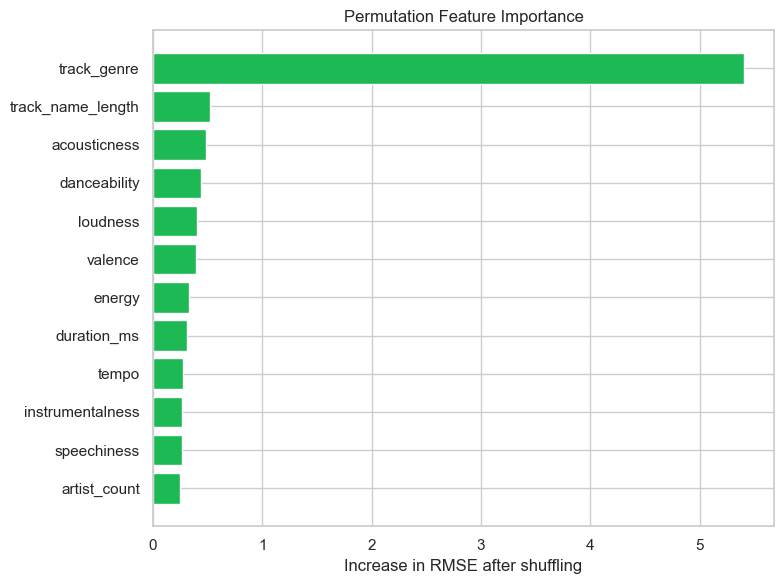

In [89]:
top = importance.head(12).sort_values("RMSE_increase")
plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["RMSE_increase"], color="#1DB954")
plt.title("Permutation Feature Importance")
plt.xlabel("Increase in RMSE after shuffling")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "spotify_permutation_importance.png", dpi=180)
plt.show()


## 9. Results Summary

Expected result from the current run:

- Best model: HistGradientBoosting.
- Audio-only features are useful but limited.
- Adding genre and metadata substantially improves prediction.
- The most important feature is usually `track_genre`, suggesting popularity depends on market and genre context, not only acoustic properties.

Important limitation: Spotify popularity is time-dependent and may depend on playlist placement, artist fame, marketing, and social trends, none of which are fully represented in this dataset.
